# EEEM068 - Sagittal ACL ViT-Small from Scratch - Part 5

**Scope:** Checkpoint loading, threshold optimisation, full evaluation, attention rollout, domain shift tests, and final summary

**Source notebook:** `sagittal_acl_scratch.ipynb`

**Notes**
- This notebook is a split component of the original final notebook.
- Some setup cells are intentionally repeated so each part is easier to understand in isolation.
- If you want to run the full pipeline end-to-end, use the original notebook or follow the README in sequence.

# EEEM068 — Knee MRI ACL Classification: ViT-Small from Scratch

## Key Constraints
- **No pretrained weights** — full training from scratch on MRNet only
- **Sagittal plane only** — binary ACL classification (positive / negative)
- **~21M parameters** — ViT-Small/16 architecture (embed_dim=384, 12 blocks, 6 heads)
- All regularisation is tuned for a small medical dataset (≈1130 training scans)

## Why training from scratch is hard here
ViT-Small normally needs ImageNet-scale data. With only 1130 scans, we compensate with:
1. **Strong augmentation** — aggressive random affine, H-flip, colour jitter, Gaussian blur
2. **MixUp + CutMix** — both applied stochastically for better generalisation
3. **Stochastic depth (DropPath)** — 0.15 rate, prevents transformer co-adaptation
4. **Heavy head dropout** — 0.5 / 0.25 in the MLP head
5. **Label smoothing** — 0.1 for binary BCE
6. **Focal loss** — focuses learning on hard/rare positive ACL cases (γ=2, α=0.75)
7. **Warmup + cosine decay** — 10-epoch warmup, essential for ViT from scratch
8. **Weight decay 0.05** — strong L2, following MAE/DINO from-scratch recipes
9. **WeightedRandomSampler** — ACL is only 18% positive, needs oversampling
10. **Gradient clipping** — max norm 1.0

## Parameter count breakdown
| Component | Parameters |
|---|---|
| Patch embedding (16×16 → 384) | 295,296 |
| Positional embedding (197 × 384) | 75,648 |
| CLS token | 384 |
| 12 × Transformer blocks | 21,233,664 |
| Layer norm | 768 |
| Classification head | 50,689 |
| **Total** | **~21.66M** |


## Section 1 — Install & Imports

In [48]:
!pip install -q timm kagglehub

In [49]:
import os, gc, math, random, warnings
from pathlib import Path
from collections import deque
from io import BytesIO
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter

import timm

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print(f"PyTorch  : {torch.__version__}")
print(f"timm     : {timm.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.11.0+cu130
timm     : 1.0.27
CUDA     : True
GPU      : NVIDIA RTX 4000 Ada Generation


## Section 2 — Configuration

All hyperparameters in one place. Key differences from a pretrained setup:

- `WARMUP_EPOCHS = 10` — ViT from scratch needs a long warmup to stabilise attention weights
- `EPOCHS = 120` — needs many more epochs without ImageNet initialisation
- `WEIGHT_DECAY = 0.05` — strong L2, follows MAE/DINO from-scratch training recipes
- `DROP_PATH_RATE = 0.15` — slightly higher stochastic depth since no pretrained regularisation
- `BASE_LR = 1e-3` — from-scratch ViT uses higher base LR than fine-tuning
- `MIN_LR = 1e-6` — cosine decay floor
- **No progressive unfreezing** — entire model trains from epoch 1

In [50]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────────
    OUT_DIR          = Path("./mrnet_scratch_acl")
    CHECKPOINT_PATH  = str(OUT_DIR / "best_vit_scratch_acl.pth")
    TENSORBOARD_DIR  = str(OUT_DIR / "tb_scratch_acl")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # ── Task ───────────────────────────────────────────────────────────────
    # Binary: ACL tear (positive=1) vs no ACL tear (negative=0)
    # Sagittal plane only
    PLANE       = "sagittal"
    LABEL       = "acl"
    NUM_CLASSES = 1  # binary sigmoid output

    # ── Model ──────────────────────────────────────────────────────────────
    IMAGE_SIZE     = 224
    MODEL_NAME     = "vit_small_patch16_224"  # 21.66M params
    DROP_PATH_RATE = 0.15  # higher than fine-tune (0.10) for scratch

    # ── MRI slice selection ────────────────────────────────────────────────
    TOP_K_SLICES = 8   # select from top-8 high-variance slices
    N_CHANNELS   = 3   # stack 3 of them as R,G,B

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE  = 8     # reduced for GPU memory; use GRAD_ACCUM to keep effective batch=16
    GRAD_ACCUM  = 2     # gradient accumulation steps → effective batch = BATCH_SIZE * GRAD_ACCUM
    EPOCHS      = 120
    MIN_EPOCHS  = 40
    PATIENCE    = 20
    NUM_WORKERS = 0     # 0 = main process only — avoids pin_memory OOM on shared/limited GPUs
    PIN_MEMORY  = False # pin_memory was the direct cause of AcceleratorError; keep False
    SEED        = 42

    # ── Learning rate (from-scratch recipe) ────────────────────────────────
    # Base LR scales with batch size: base_lr * (batch_size / 256)
    # base_lr = 1e-3 is the standard ViT from-scratch value
    BASE_LR      = 1e-3 * (BATCH_SIZE / 256)  # ~6.25e-5 for batch=16
    HEAD_LR      = 5e-4   # head gets a slightly higher LR
    MIN_LR       = 1e-6
    WEIGHT_DECAY = 0.05   # strong L2, MAE-style
    WARMUP_EPOCHS = 10    # long warmup for from-scratch ViT

    # ── Regularisation ─────────────────────────────────────────────────────
    DROPOUT_HEAD1  = 0.50   # heavier dropout for small dataset
    DROPOUT_HEAD2  = 0.25
    LABEL_SMOOTH   = 0.10   # 0.10 for binary (0→0.05, 1→0.95)

    # ── MixUp & CutMix ─────────────────────────────────────────────────────
    MIXUP_ALPHA    = 0.4    # Beta(0.4, 0.4) for MixUp
    CUTMIX_ALPHA   = 1.0    # Beta(1.0, 1.0) for CutMix
    MIXUP_PROB     = 0.5    # probability of applying either augmentation
    MIXUP_CUTMIX_SPLIT = 0.5  # 50/50 split between MixUp and CutMix

    # ── Focal Loss ─────────────────────────────────────────────────────────
    FOCAL_GAMMA = 2.0   # focusing parameter: 2.0 is standard
    FOCAL_ALPHA = 0.75  # weight for positive class (ACL positive is rare)

    # ── TTA ────────────────────────────────────────────────────────────────
    TTA_N = 8           # test-time augmentation passes

    # ── Threshold ──────────────────────────────────────────────────────────
    # Optimised on validation set after training
    THRESHOLD = 0.5     # updated by find_optimal_threshold()

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CFG loaded")
print(f"  Task         : {CFG.LABEL.upper()} binary (sagittal only)")
print(f"  Pretrained   : NONE — from scratch")
print(f"  Device       : {CFG.DEVICE}")
print(f"  Base LR      : {CFG.BASE_LR:.2e}")
print(f"  Weight decay : {CFG.WEIGHT_DECAY}")
print(f"  Warmup       : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Epochs       : {CFG.EPOCHS}")

CFG loaded
  Task         : ACL binary (sagittal only)
  Pretrained   : NONE — from scratch
  Device       : cuda
  Base LR      : 3.13e-05
  Weight decay : 0.05
  Warmup       : 10 epochs
  Epochs       : 120


## Section 3 — Dataset Download & Labels

In [51]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET SETUP — three options, use whichever fits your environment
# ═══════════════════════════════════════════════════════════════════════════

# ── Option A: Already extracted manually ──────────────────────────────────
# If you downloaded and unzipped the dataset yourself, just set the path here
# and skip everything else. The folder must contain train/, valid/, and the
# six CSV label files.
#
# MANUAL_ROOT = "/path/to/MRNet-v1.0"   # ← set this
# CFG.ROOT = Path(MANUAL_ROOT)
# assert CFG.ROOT.exists(), f"Dataset not found: {CFG.ROOT}"
# print(f"✓ Dataset at: {CFG.ROOT}")


# ── Option B: Streaming — extract ONLY sagittal + labels (saves ~5 GB) ────
# Avoids the 'No space left on device' error by extracting only the files
# we actually need (sagittal plane + CSV labels) from the zip.
# The full zip is ~6 GB but sagittal + labels is only ~2 GB.

import zipfile, glob

# Find the already-downloaded zip in kagglehub cache
# kagglehub stores downloads at ~/.cache/kagglehub/datasets/cjinny/mrnet-v1/
CACHE_GLOB = os.path.expanduser(
    "~/.cache/kagglehub/datasets/cjinny/mrnet-v1/versions/*/mrnet-v1.zip"
)
zip_candidates = glob.glob(CACHE_GLOB)

# Also check the raw download path if kagglehub used a different layout
if not zip_candidates:
    CACHE_GLOB2 = os.path.expanduser(
        "~/.cache/kagglehub/datasets/cjinny/mrnet-v1/**/*.zip"
    )
    zip_candidates = glob.glob(CACHE_GLOB2, recursive=True)

EXTRACT_DIR = Path(os.path.expanduser("~/Downloads/AML/mrnet_sagittal_only"))
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if zip_candidates:
    zip_path = zip_candidates[0]
    print(f"Found zip: {zip_path}")
    print(f"Extracting sagittal + labels only → {EXTRACT_DIR}")

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_names = z.namelist()
        # Keep only sagittal .npy files and all .csv label files
        to_extract = [
            n for n in all_names
            if '/sagittal/' in n or n.endswith('.csv')
        ]
        print(f"  Total files in zip : {len(all_names)}")
        print(f"  Files to extract   : {len(to_extract)} (sagittal + csv)")

        for i, name in enumerate(to_extract):
            z.extract(name, EXTRACT_DIR)
            if (i + 1) % 200 == 0:
                print(f"  Extracted {i+1}/{len(to_extract)}...", end="\r")

    print(f"\n✓ Extraction complete")
    CFG.ROOT = EXTRACT_DIR / "MRNet-v1.0"

else:
    # ── Option C: Download fresh with kagglehub to a custom output directory
    # This lets you point extraction at a drive/partition with more space.
    print("No cached zip found — downloading via kagglehub...")
    print("Tip: if you get 'No space left', manually download the zip from:")
    print("  https://www.kaggle.com/datasets/cjinny/mrnet-v1")
    print("and set MANUAL_ROOT in Option A above.")

    import kagglehub
    # Set output_dir to a path with enough space
    dl_path  = kagglehub.dataset_download(
        "cjinny/mrnet-v1",
        output_dir=str(EXTRACT_DIR)  # extract here instead of cache
    )
    CFG.ROOT = Path(dl_path) / "MRNet-v1.0"

assert CFG.ROOT.exists(), (
    f"Dataset root not found: {CFG.ROOT}\n"
    f"Please set MANUAL_ROOT in Option A and uncomment those lines."
)
print(f"✓ Dataset root: {CFG.ROOT}")

# Verify the structure we need exists
for split in ['train', 'valid']:
    sag_dir = CFG.ROOT / split / 'sagittal'
    csv_file = CFG.ROOT / f'{split}-acl.csv'
    assert sag_dir.exists(), f"Missing: {sag_dir}"
    assert csv_file.exists(), f"Missing: {csv_file}"
    n_npy = len(list(sag_dir.glob('*.npy')))
    print(f"  {split}/sagittal/ : {n_npy} .npy files  |  {split}-acl.csv ✓")

No cached zip found — downloading via kagglehub...
Tip: if you get 'No space left', manually download the zip from:
  https://www.kaggle.com/datasets/cjinny/mrnet-v1
and set MANUAL_ROOT in Option A above.
✓ Dataset root: /user/HS402/lt01109/Downloads/AML/mrnet_sagittal_only/MRNet-v1.0
  train/sagittal/ : 1130 .npy files  |  train-acl.csv ✓
  valid/sagittal/ : 120 .npy files  |  valid-acl.csv ✓


In [52]:
def load_labels(root, split):
    """
    Load labels for binary ACL classification.
    Returns a DataFrame with columns: id, acl, sagittal_path, label
    """
    acl_df = pd.read_csv(root / f"{split}-acl.csv", header=None, names=["id", "acl"])
    acl_df["id"] = acl_df["id"].astype(str).str.zfill(4)
    acl_df["sagittal_path"] = acl_df["id"].apply(
        lambda x: str(root / split / "sagittal" / f"{x}.npy")
    )
    acl_df["label"] = acl_df["acl"].astype(float)
    return acl_df

train_df = load_labels(CFG.ROOT, "train")
valid_df = load_labels(CFG.ROOT, "valid")

n_pos_train = int(train_df["label"].sum())
n_pos_valid = int(valid_df["label"].sum())

print(f"Train : {len(train_df)} scans  |  ACL+ = {n_pos_train} ({100*n_pos_train/len(train_df):.1f}%)  ACL- = {len(train_df)-n_pos_train}")
print(f"Valid : {len(valid_df)} scans  |  ACL+ = {n_pos_valid} ({100*n_pos_valid/len(valid_df):.1f}%)  ACL- = {len(valid_df)-n_pos_valid}")
print(f"Class imbalance ratio: {(len(train_df)-n_pos_train)/n_pos_train:.2f}:1 (neg:pos)")

Train : 1130 scans  |  ACL+ = 208 (18.4%)  ACL- = 922
Valid : 120 scans  |  ACL+ = 54 (45.0%)  ACL- = 66
Class imbalance ratio: 4.43:1 (neg:pos)


## Section 5 — Preprocessing & Dataset

**Slice selection strategy:**
MRI volumes have variable depth (typically 20–35 slices for sagittal). We rank all slices by pixel variance — high variance means structural content rather than blank background or artifact. The top-K are selected and 3 are chosen spread evenly to cover anterior, mid, and posterior knee regions. These become the R, G, B channels.

**Dataset-specific normalisation (not ImageNet):**
Since we train from scratch, we compute MRNet-specific mean/std from a random sample of training volumes rather than using ImageNet statistics. This is critical — ImageNet stats are wrong for MRI data.

**Training augmentation (stronger for from-scratch):**
- Random rotation ±20°
- Random translation ±12% X and Y
- Random scaling 80–120%
- Random horizontal flip
- Colour jitter (brightness, contrast)
- Random Gaussian blur
- Random erasing (simulates MRI artefacts)

In [54]:
def compute_dataset_stats(df, n_samples=150, top_k=8, n_ch=3):
    """
    Compute mean and std from MRNet training data instead of using ImageNet stats.
    Samples n_samples volumes and estimates statistics per channel.
    This is important for from-scratch training — ImageNet stats are incorrect for MRI.
    """
    print(f"Computing dataset statistics from {n_samples} random training scans...")
    sample_df = df.sample(min(n_samples, len(df)), random_state=42)
    all_pixels = [[] for _ in range(n_ch)]

    for _, row in sample_df.iterrows():
        vol = np.load(row["sagittal_path"], mmap_mode="r")
        D   = vol.shape[0]
        var = np.var(vol.reshape(D, -1), axis=1)
        topk = np.sort(np.argsort(var)[-min(top_k, D):])
        chosen = topk[np.linspace(0, len(topk)-1, n_ch, dtype=int)]
        for ch, idx in enumerate(chosen):
            s = vol[idx].astype(np.float32)
            lo, hi = s.min(), s.max()
            s = (s - lo) / (hi - lo + 1e-8)  # [0, 1]
            all_pixels[ch].append(s.flatten())

    means = [np.concatenate(c).mean() for c in all_pixels]
    stds  = [np.concatenate(c).std()  for c in all_pixels]
    print(f"  MRNet mean : {[f'{m:.4f}' for m in means]}")
    print(f"  MRNet std  : {[f'{s:.4f}' for s in stds]}")
    return means, stds

MRNET_MEAN, MRNET_STD = compute_dataset_stats(train_df)

Computing dataset statistics from 150 random training scans...
  MRNet mean : ['0.2190', '0.2299', '0.2180']
  MRNet std  : ['0.1992', '0.1989', '0.1983']


In [55]:
def select_topk_variance_slices(volume, top_k=8, n_out=3):
    """Rank slices by pixel variance, select n_out spread evenly across the top-K."""
    D    = volume.shape[0]
    var  = np.var(volume.reshape(D, -1), axis=1)
    topk = np.sort(np.argsort(var)[-min(top_k, D):])
    n_out = min(n_out, len(topk))
    chosen = topk[np.linspace(0, len(topk)-1, n_out, dtype=int)]
    if len(chosen) < n_out:
        chosen = np.pad(chosen, (0, n_out - len(chosen)), mode="edge")
    return volume[chosen]


def volume_to_rgb(volume, top_k=8, n_ch=3):
    """3D MRI volume → pseudo-RGB PIL image using per-slice min-max normalisation."""
    slices = select_topk_variance_slices(volume, top_k=top_k, n_out=n_ch)
    channels = []
    for s in slices:
        s = s.astype(np.float32)
        lo, hi = s.min(), s.max()
        s = (s - lo) / (hi - lo + 1e-8)
        channels.append((s * 255).clip(0, 255).astype(np.uint8))
    return Image.fromarray(np.stack(channels, axis=-1))


# ── Transforms ─────────────────────────────────────────────────────────────
# From scratch needs stronger augmentation than fine-tuning
train_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(
        degrees=20,
        translate=(0.12, 0.12),
        scale=(0.80, 1.20),
        fill=0
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=MRNET_MEAN, std=MRNET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3)),
])

tta_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.92, 1.08), fill=0),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=MRNET_MEAN, std=MRNET_STD),
])

valid_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MRNET_MEAN, std=MRNET_STD),
])

print("✓ Transforms defined (MRNet normalisation, not ImageNet)")

✓ Transforms defined (MRNet normalisation, not ImageNet)


In [56]:
class MRNetACLDataset(Dataset):
    """
    Binary ACL classification from sagittal MRI volumes.
    Each volume is converted to a pseudo-RGB image using the top-K
    high-variance slices.
    """
    def __init__(self, df, transforms=None, top_k=8, n_ch=3):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms
        self.top_k      = top_k
        self.n_ch       = n_ch

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        vol = np.load(row["sagittal_path"], mmap_mode="r")
        img = volume_to_rgb(vol, top_k=self.top_k, n_ch=self.n_ch)
        if self.transforms:
            img = self.transforms(img)
        label = torch.tensor([row["label"]], dtype=torch.float32)  # shape (1,)
        return img, label, row["id"]

# Quick sanity check
ds_check = MRNetACLDataset(train_df.head(3), transforms=train_tfm)
img, lbl, eid = ds_check[0]
print(f"Image tensor : {tuple(img.shape)}")
print(f"Label        : {lbl}  (ACL {'positive' if lbl[0]==1 else 'negative'})")
print(f"Exam ID      : {eid}")

Image tensor : (3, 224, 224)
Label        : tensor([0.])  (ACL negative)
Exam ID      : 0000


## Section 8 — Model: ViT-Small from Scratch (~21.66M params)

Architecture: `vit_small_patch16_224` via timm.
- 12 Transformer blocks
- embed_dim = 384
- 6 attention heads, head_dim = 64
- patch_size = 16 → 14×14 = 196 patches + 1 CLS = 197 tokens
- `pretrained=False` — random initialisation, no ImageNet weights

**Weight initialisation (critical for from-scratch ViT):**
- Linear layers: truncated normal (σ=0.02), following ViT paper
- LayerNorm: weight=1, bias=0
- QKV bias: zeros
- Positional embedding: truncated normal (σ=0.02)
- CLS token: zeros

**Classification head:** LayerNorm → Linear(384, 256) → GELU → Dropout(0.5) → Linear(256, 128) → GELU → Dropout(0.25) → Linear(128, 1)
Binary output — sigmoid applied at inference, not in forward pass (BCEWithLogitsLoss handles it).

In [60]:
class ViTScratchACL(nn.Module):
    """
    ViT-Small for binary ACL classification, trained entirely from scratch.

    Architecture:
    - Backbone: timm vit_small_patch16_224 (pretrained=False)
      12 blocks, embed_dim=384, 6 heads, patch_size=16
      ~21.66M parameters
    - Head: 4-layer MLP with heavy dropout for small-dataset regularisation
      ~50K parameters
    - Total: ~21.71M parameters

    Key differences from fine-tuning setup:
    - Higher drop_path_rate (0.15 vs 0.10)
    - Heavier head dropout (0.5 vs 0.35)
    - Xavier/trunc-normal init applied to head
    - No layer freezing / progressive unfreezing needed
    """

    def __init__(self, num_classes=1):
        super().__init__()

        # Backbone — NO pretrained weights
        self.backbone = timm.create_model(
            CFG.MODEL_NAME,
            pretrained=False,          # ← from scratch
            num_classes=0,             # remove timm's default head
            drop_path_rate=CFG.DROP_PATH_RATE,
            img_size=CFG.IMAGE_SIZE,
        )

        D = self.backbone.num_features  # 384 for ViT-Small

        # Classification head — 4-layer MLP
        self.head = nn.Sequential(
            nn.LayerNorm(D),
            nn.Linear(D, 256),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT_HEAD1),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(CFG.DROPOUT_HEAD2),
            nn.Linear(128, num_classes),
        )

        # Initialise head weights explicitly
        self._init_head()

        # Apply proper initialisation to backbone (timm does this by default
        # for pretrained=True but we need to verify for pretrained=False)
        self._verify_backbone_init()

    def _init_head(self):
        """Xavier uniform for linear layers, const for norms."""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _verify_backbone_init(self):
        """Confirm backbone is randomly initialised (no pretrained checkpoint)."""
        # timm initialises with trunc_normal_(std=0.02) for pretrained=False
        # Patch embed weight should NOT be all zeros
        pe_weight = self.backbone.patch_embed.proj.weight
        assert pe_weight.abs().max() > 0, "Patch embed weight is all-zero — init failed"
        print(f"  Backbone init verified — patch embed std: {pe_weight.std():.4f}")

    def forward(self, x):
        """
        x : (B, 3, 224, 224) pseudo-RGB sagittal MRI
        returns: (B, 1) raw logits (apply sigmoid for probability)
        """
        features = self.backbone(x)  # (B, 384) — CLS token features
        return self.head(features)   # (B, 1)

    def get_param_groups(self, head_lr, backbone_lr, wd):
        """
        Two parameter groups:
        - Head: higher LR (randomly initialised, needs to learn faster)
        - Backbone: lower LR (random but structured init, more sensitive)

        Note: no progressive unfreezing for from-scratch. Both groups train
        from epoch 1. The backbone LR is still lower than the head to prevent
        the randomly initialised head from destabilising the backbone early.
        """
        return [
            {"params": self.head.parameters(),
             "lr": head_lr, "weight_decay": wd},
            {"params": self.backbone.parameters(),
             "lr": backbone_lr, "weight_decay": wd},
        ]

    def param_count(self):
        total     = sum(p.numel() for p in self.parameters())
        backbone  = sum(p.numel() for p in self.backbone.parameters())
        head      = sum(p.numel() for p in self.head.parameters())
        return total, backbone, head


# Instantiate
model = ViTScratchACL(num_classes=1).to(CFG.DEVICE)
total, backbone, head_p = model.param_count()

print(f"\nModel: ViT-Small from scratch (NO pretrained weights)")
print(f"  Backbone parameters : {backbone:>12,}")
print(f"  Head parameters     : {head_p:>12,}")
print(f"  Total parameters    : {total:>12,}  ({total/1e6:.2f}M)")

# Quick forward pass test
dummy = torch.randn(2, 3, 224, 224).to(CFG.DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"\nForward pass test — output shape: {tuple(out.shape)}  ✓")

  Backbone init verified — patch embed std: 0.0208

Model: ViT-Small from scratch (NO pretrained weights)
  Backbone parameters :   21,665,664
  Head parameters     :      132,353
  Total parameters    :   21,798,017  (21.80M)

Forward pass test — output shape: (2, 1)  ✓


## Section 9 — Loss, Optimiser & Scheduler

### Focal Loss for Binary Classification
Standard BCE suffers on ACL (18% positive). Focal loss adds a modulating factor that downweights easy correct predictions:
```
FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
```
- `gamma=2.0` — standard value from Lin et al. 2017 RetinaNet
- `alpha=0.75` — positive class weighted 3x more than negative

### MixUp and CutMix
Both applied stochastically (50/50 split, 50% probability per batch):
- **MixUp**: linear blend of two images and labels
- **CutMix**: paste a rectangular crop from one image into another; labels mixed proportionally by crop area

### Cosine LR with Long Warmup
From-scratch ViT requires a long linear warmup (10 epochs here) before cosine decay. Without warmup, attention weights collapse early in training.

In [61]:
class FocalBCELoss(nn.Module):
    """
    Binary Focal Loss for imbalanced ACL classification.

    Args:
        gamma (float): focusing parameter. gamma=0 → standard BCE.
                       gamma=2 reduces loss from easy examples by ~4x at p=0.9.
        alpha (float): weight for positive class. alpha=0.75 → positive
                       class contributes 3x more than negative.
        smoothing (float): label smoothing. 0.10 → targets become {0.05, 0.95}.
    """
    def __init__(self, gamma=2.0, alpha=0.75, smoothing=0.10):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.smoothing = smoothing

    def forward(self, logits, targets):
        # Label smoothing
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing

        # Standard BCE
        bce = F.binary_cross_entropy_with_logits(
            logits, targets_smooth, reduction="none"
        )

        # Compute p_t
        p    = torch.sigmoid(logits)
        p_t  = p * targets + (1 - p) * (1 - targets)

        # Alpha weighting
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Focal weight
        focal_weight = alpha_t * (1 - p_t) ** self.gamma

        return (focal_weight * bce).mean()


def mixup_batch(imgs, targets, alpha):
    """MixUp augmentation: linear blend of two samples."""
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0))
    mixed_imgs    = lam * imgs    + (1 - lam) * imgs[perm]
    mixed_targets = lam * targets + (1 - lam) * targets[perm]
    return mixed_imgs, mixed_targets


def cutmix_batch(imgs, targets, alpha):
    """
    CutMix augmentation: replace a random rectangular region with a crop
    from another sample. Labels are mixed proportionally to area.
    """
    lam  = np.random.beta(alpha, alpha)
    perm = torch.randperm(imgs.size(0))
    B, C, H, W = imgs.shape

    # Random bounding box
    cut_ratio = math.sqrt(1 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx = random.randint(0, W)
    cy = random.randint(0, H)
    x1 = max(0, cx - cut_w // 2)
    y1 = max(0, cy - cut_h // 2)
    x2 = min(W, cx + cut_w // 2)
    y2 = min(H, cy + cut_h // 2)

    mixed = imgs.clone()
    mixed[:, :, y1:y2, x1:x2] = imgs[perm, :, y1:y2, x1:x2]

    # Adjust lambda for actual cut area
    lam = 1 - ((y2 - y1) * (x2 - x1)) / (H * W)
    mixed_targets = lam * targets + (1 - lam) * targets[perm]
    return mixed, mixed_targets


def apply_mix_augmentation(imgs, targets):
    """Apply MixUp or CutMix stochastically."""
    if random.random() >= CFG.MIXUP_PROB:
        return imgs, targets  # no augmentation
    if random.random() < CFG.MIXUP_CUTMIX_SPLIT:
        return mixup_batch(imgs, targets, CFG.MIXUP_ALPHA)
    else:
        return cutmix_batch(imgs, targets, CFG.CUTMIX_ALPHA)


def make_cosine_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs, min_lr):
    """
    Linear warmup followed by cosine annealing down to min_lr.
    Critical for from-scratch ViT — without warmup attention weights collapse.
    """
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        cosine   = 0.5 * (1 + math.cos(math.pi * progress))
        # Scale cosine so it decays to min_lr, not 0
        base_lr  = optimizer.param_groups[0]["lr"]
        if base_lr > 0:
            floor = min_lr / base_lr
            return floor + (1 - floor) * cosine
        return cosine
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# Instantiate loss and optimiser
criterion = FocalBCELoss(
    gamma=CFG.FOCAL_GAMMA,
    alpha=CFG.FOCAL_ALPHA,
    smoothing=CFG.LABEL_SMOOTH
)

optimizer = torch.optim.AdamW(
    model.get_param_groups(
        head_lr=CFG.HEAD_LR,
        backbone_lr=CFG.BASE_LR,
        wd=CFG.WEIGHT_DECAY
    )
)

scheduler = make_cosine_scheduler_with_warmup(
    optimizer,
    warmup_epochs=CFG.WARMUP_EPOCHS,
    total_epochs=CFG.EPOCHS,
    min_lr=CFG.MIN_LR
)

writer = SummaryWriter(CFG.TENSORBOARD_DIR)

print("Training setup:")
print(f"  Loss      : Focal BCE (gamma={CFG.FOCAL_GAMMA}, alpha={CFG.FOCAL_ALPHA})")
print(f"  Smoothing : {CFG.LABEL_SMOOTH}")
print(f"  Optimiser : AdamW")
print(f"  Head LR   : {CFG.HEAD_LR:.2e}")
print(f"  Backbone LR: {CFG.BASE_LR:.2e}")
print(f"  Weight decay: {CFG.WEIGHT_DECAY}")
print(f"  Warmup    : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Mix augment: MixUp (α={CFG.MIXUP_ALPHA}) + CutMix (α={CFG.CUTMIX_ALPHA}), p={CFG.MIXUP_PROB}")





Training setup:
  Loss      : Focal BCE (gamma=2.0, alpha=0.75)
  Smoothing : 0.1
  Optimiser : AdamW
  Head LR   : 5.00e-04
  Backbone LR: 3.13e-05
  Weight decay: 0.05
  Warmup    : 10 epochs
  Mix augment: MixUp (α=0.4) + CutMix (α=1.0), p=0.5


## Section 13 — Load Best Checkpoint & Threshold Optimisation

The default threshold of 0.5 may not be optimal for imbalanced ACL data. We search the threshold that maximises F1-score (or you can use the Youden index for sensitivity/specificity balance).

In [70]:
ckpt = torch.load(CFG.CHECKPOINT_PATH, map_location=CFG.DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
print(f"  Val F1  : {ckpt['val_f1']:.4f}")
print(f"  Val AUC : {ckpt['val_auc']:.4f}")

# ── TTA Evaluation ─────────────────────────────────────────────────────────
def evaluate_with_tta(model, df, device, n_tta=8):
    """
    Test-time augmentation: run each scan n_tta times with random augmentation
    and average the predicted probabilities. Reduces variance in predictions.
    """
    model.eval()
    all_probs   = []
    all_targets = []

    ds_tta = MRNetACLDataset(df, transforms=None,
                              top_k=CFG.TOP_K_SLICES, n_ch=CFG.N_CHANNELS)

    for idx in range(len(ds_tta)):
        vol = np.load(df.iloc[idx]["sagittal_path"], mmap_mode="r")
        img_pil = volume_to_rgb(vol, top_k=CFG.TOP_K_SLICES, n_ch=CFG.N_CHANNELS)
        label   = float(df.iloc[idx]["label"])

        probs_i = []
        # 1 clean pass + (n_tta-1) augmented passes
        for j in range(n_tta):
            tfm = valid_tfm if j == 0 else tta_tfm
            t   = tfm(img_pil).unsqueeze(0).to(device)
            with torch.no_grad():
                p = torch.sigmoid(model(t)).item()
            probs_i.append(p)

        all_probs.append(np.mean(probs_i))
        all_targets.append(int(label))

    return np.array(all_targets), np.array(all_probs)


print(f"\nRunning TTA evaluation ({CFG.TTA_N} passes per scan)...")
y_true, y_probs_tta = evaluate_with_tta(model, valid_df, CFG.DEVICE, n_tta=CFG.TTA_N)
print(f"✓ TTA complete — {len(y_true)} scans evaluated")

Loaded checkpoint from epoch 6
  Val F1  : 0.6207
  Val AUC : 0.7402

Running TTA evaluation (8 passes per scan)...
✓ TTA complete — 120 scans evaluated


In [71]:
def find_optimal_threshold(y_true, y_probs, metric="f1"):
    """
    Search threshold in [0.1, 0.9] that maximises the chosen metric.
    metric: 'f1' (maximise F1) or 'youden' (maximise sensitivity + specificity - 1)
    """
    thresholds  = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    best_score  = -1.0

    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        if metric == "f1":
            score = f1_score(y_true, preds, zero_division=0)
        elif metric == "youden":
            tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
            sens  = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec  = tn / (tn + fp) if (tn + fp) > 0 else 0
            score = sens + spec - 1
        if score > best_score:
            best_score  = score
            best_thresh = t

    return best_thresh, best_score


opt_thresh_f1, best_f1_val   = find_optimal_threshold(y_true, y_probs_tta, "f1")
opt_thresh_youden, best_youd = find_optimal_threshold(y_true, y_probs_tta, "youden")

print(f"Optimal threshold (F1 max)    : {opt_thresh_f1:.2f}  → F1={best_f1_val:.4f}")
print(f"Optimal threshold (Youden)    : {opt_thresh_youden:.2f}  → J={best_youd:.4f}")
print(f"Default threshold             : 0.50")

CFG.THRESHOLD = opt_thresh_f1
print(f"\nUsing threshold: {CFG.THRESHOLD:.2f} (F1-optimal)")

Optimal threshold (F1 max)    : 0.51  → F1=0.6557
Optimal threshold (Youden)    : 0.51  → J=0.3165
Default threshold             : 0.50

Using threshold: 0.51 (F1-optimal)


## Section 14 — Full Evaluation

In [72]:
y_preds = (y_probs_tta >= CFG.THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_preds).ravel()

metrics = {
    "Accuracy"          : accuracy_score(y_true, y_preds),
    "Balanced Accuracy" : balanced_accuracy_score(y_true, y_preds),
    "Sensitivity"       : tp / (tp + fn) if (tp + fn) > 0 else 0,
    "Specificity"       : tn / (tn + fp) if (tn + fp) > 0 else 0,
    "Precision"         : tp / (tp + fp) if (tp + fp) > 0 else 0,
    "F1-Score"          : f1_score(y_true, y_preds, zero_division=0),
    "AUC-ROC"           : roc_auc_score(y_true, y_probs_tta),
}

print("=" * 55)
print("  TABLE 1 — ACL Classification (Sagittal, Scratch)")
print(f"  Validation set (n={len(y_true)}) | Threshold={CFG.THRESHOLD:.2f}")
print("=" * 55)
for k, v in metrics.items():
    print(f"  {k:<22}: {v:.4f}")
print("=" * 55)

# Save to CSV
pd.DataFrame([metrics]).to_csv(CFG.OUT_DIR / "eval_metrics.csv", index=False)
print("\nClassification Report (threshold=0.5 and optimal):")
print(classification_report(y_true, y_preds,
                             target_names=["ACL-", "ACL+"], digits=4))

  TABLE 1 — ACL Classification (Sagittal, Scratch)
  Validation set (n=120) | Threshold=0.51
  Accuracy              : 0.6500
  Balanced Accuracy     : 0.6582
  Sensitivity           : 0.7407
  Specificity           : 0.5758
  Precision             : 0.5882
  F1-Score              : 0.6557
  AUC-ROC               : 0.7402

Classification Report (threshold=0.5 and optimal):
              precision    recall  f1-score   support

        ACL-     0.7308    0.5758    0.6441        66
        ACL+     0.5882    0.7407    0.6557        54

    accuracy                         0.6500       120
   macro avg     0.6595    0.6582    0.6499       120
weighted avg     0.6666    0.6500    0.6493       120



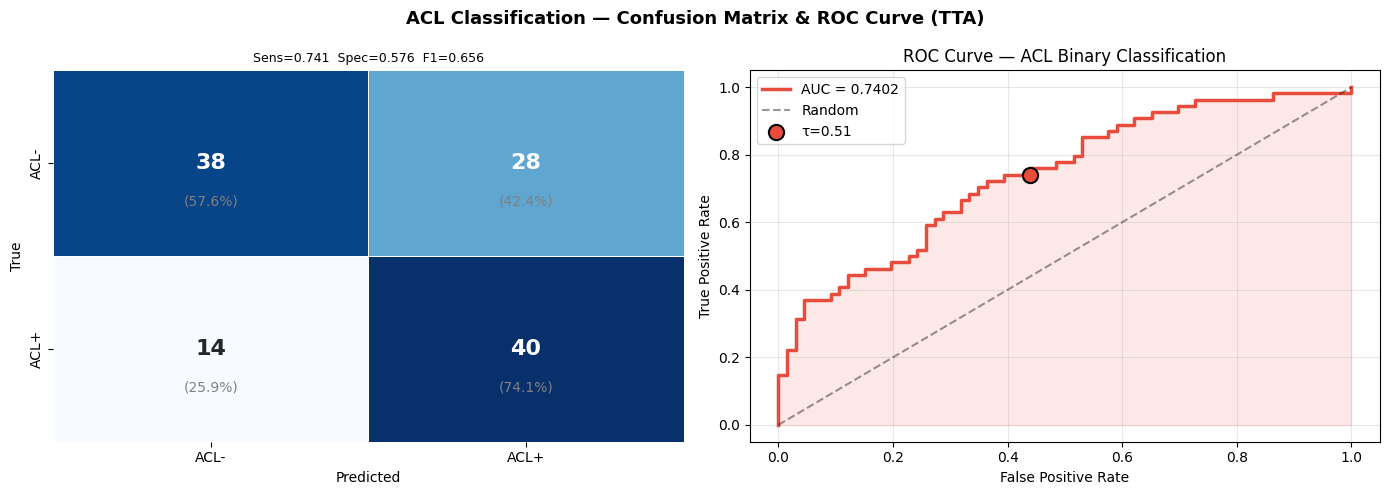

✓ Saved: confusion_roc.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ACL Classification — Confusion Matrix & ROC Curve (TTA)",
             fontsize=13, fontweight="bold")

# Confusion matrix
cm = confusion_matrix(y_true, y_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["ACL-", "ACL+"],
            yticklabels=["ACL-", "ACL+"],
            linewidths=0.5, cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
for (r, c), v in np.ndenumerate(cm):
    axes[0].text(c + 0.5, r + 0.73, f"({100*cm_norm[r,c]:.1f}%)",
                 ha="center", fontsize=10, color="gray")
axes[0].set_title(
    f"Sens={metrics['Sensitivity']:.3f}  Spec={metrics['Specificity']:.3f}  "
    f"F1={metrics['F1-Score']:.3f}",
    fontsize=9
)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# ROC curve
fpr, tpr, thrs = roc_curve(y_true, y_probs_tta)
auc_score = roc_auc_score(y_true, y_probs_tta)
axes[1].plot(fpr, tpr, color="#E74C3C", lw=2.5, label=f"AUC = {auc_score:.4f}")
axes[1].fill_between(fpr, tpr, alpha=0.12, color="#E74C3C")
axes[1].plot([0,1],[0,1], "k--", alpha=0.4, label="Random")
# Mark optimal threshold point
opt_idx = np.argmin(np.abs(thrs - CFG.THRESHOLD))
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], s=120, color="#E74C3C", zorder=5,
                edgecolors="black", lw=1.5, label=f"τ={CFG.THRESHOLD:.2f}")
axes[1].set_title("ROC Curve — ACL Binary Classification")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: confusion_roc.png")

## Section 15 — Attention Rollout Visualisation

Attention Rollout (Abnar & Zuidema, 2020) propagates multi-head attention maps layer-by-layer back to the input patches. The resulting spatial map shows which 16×16 patches the CLS token attends to when making the ACL classification decision.

**Clinically, we expect the model to attend to the ACL region** — the anterior cruciate ligament appears as a band crossing the knee joint on sagittal MRI. Attention maps that highlight this region (rather than background or bone) suggest the model has learned relevant anatomy despite no pretrained initialisation.

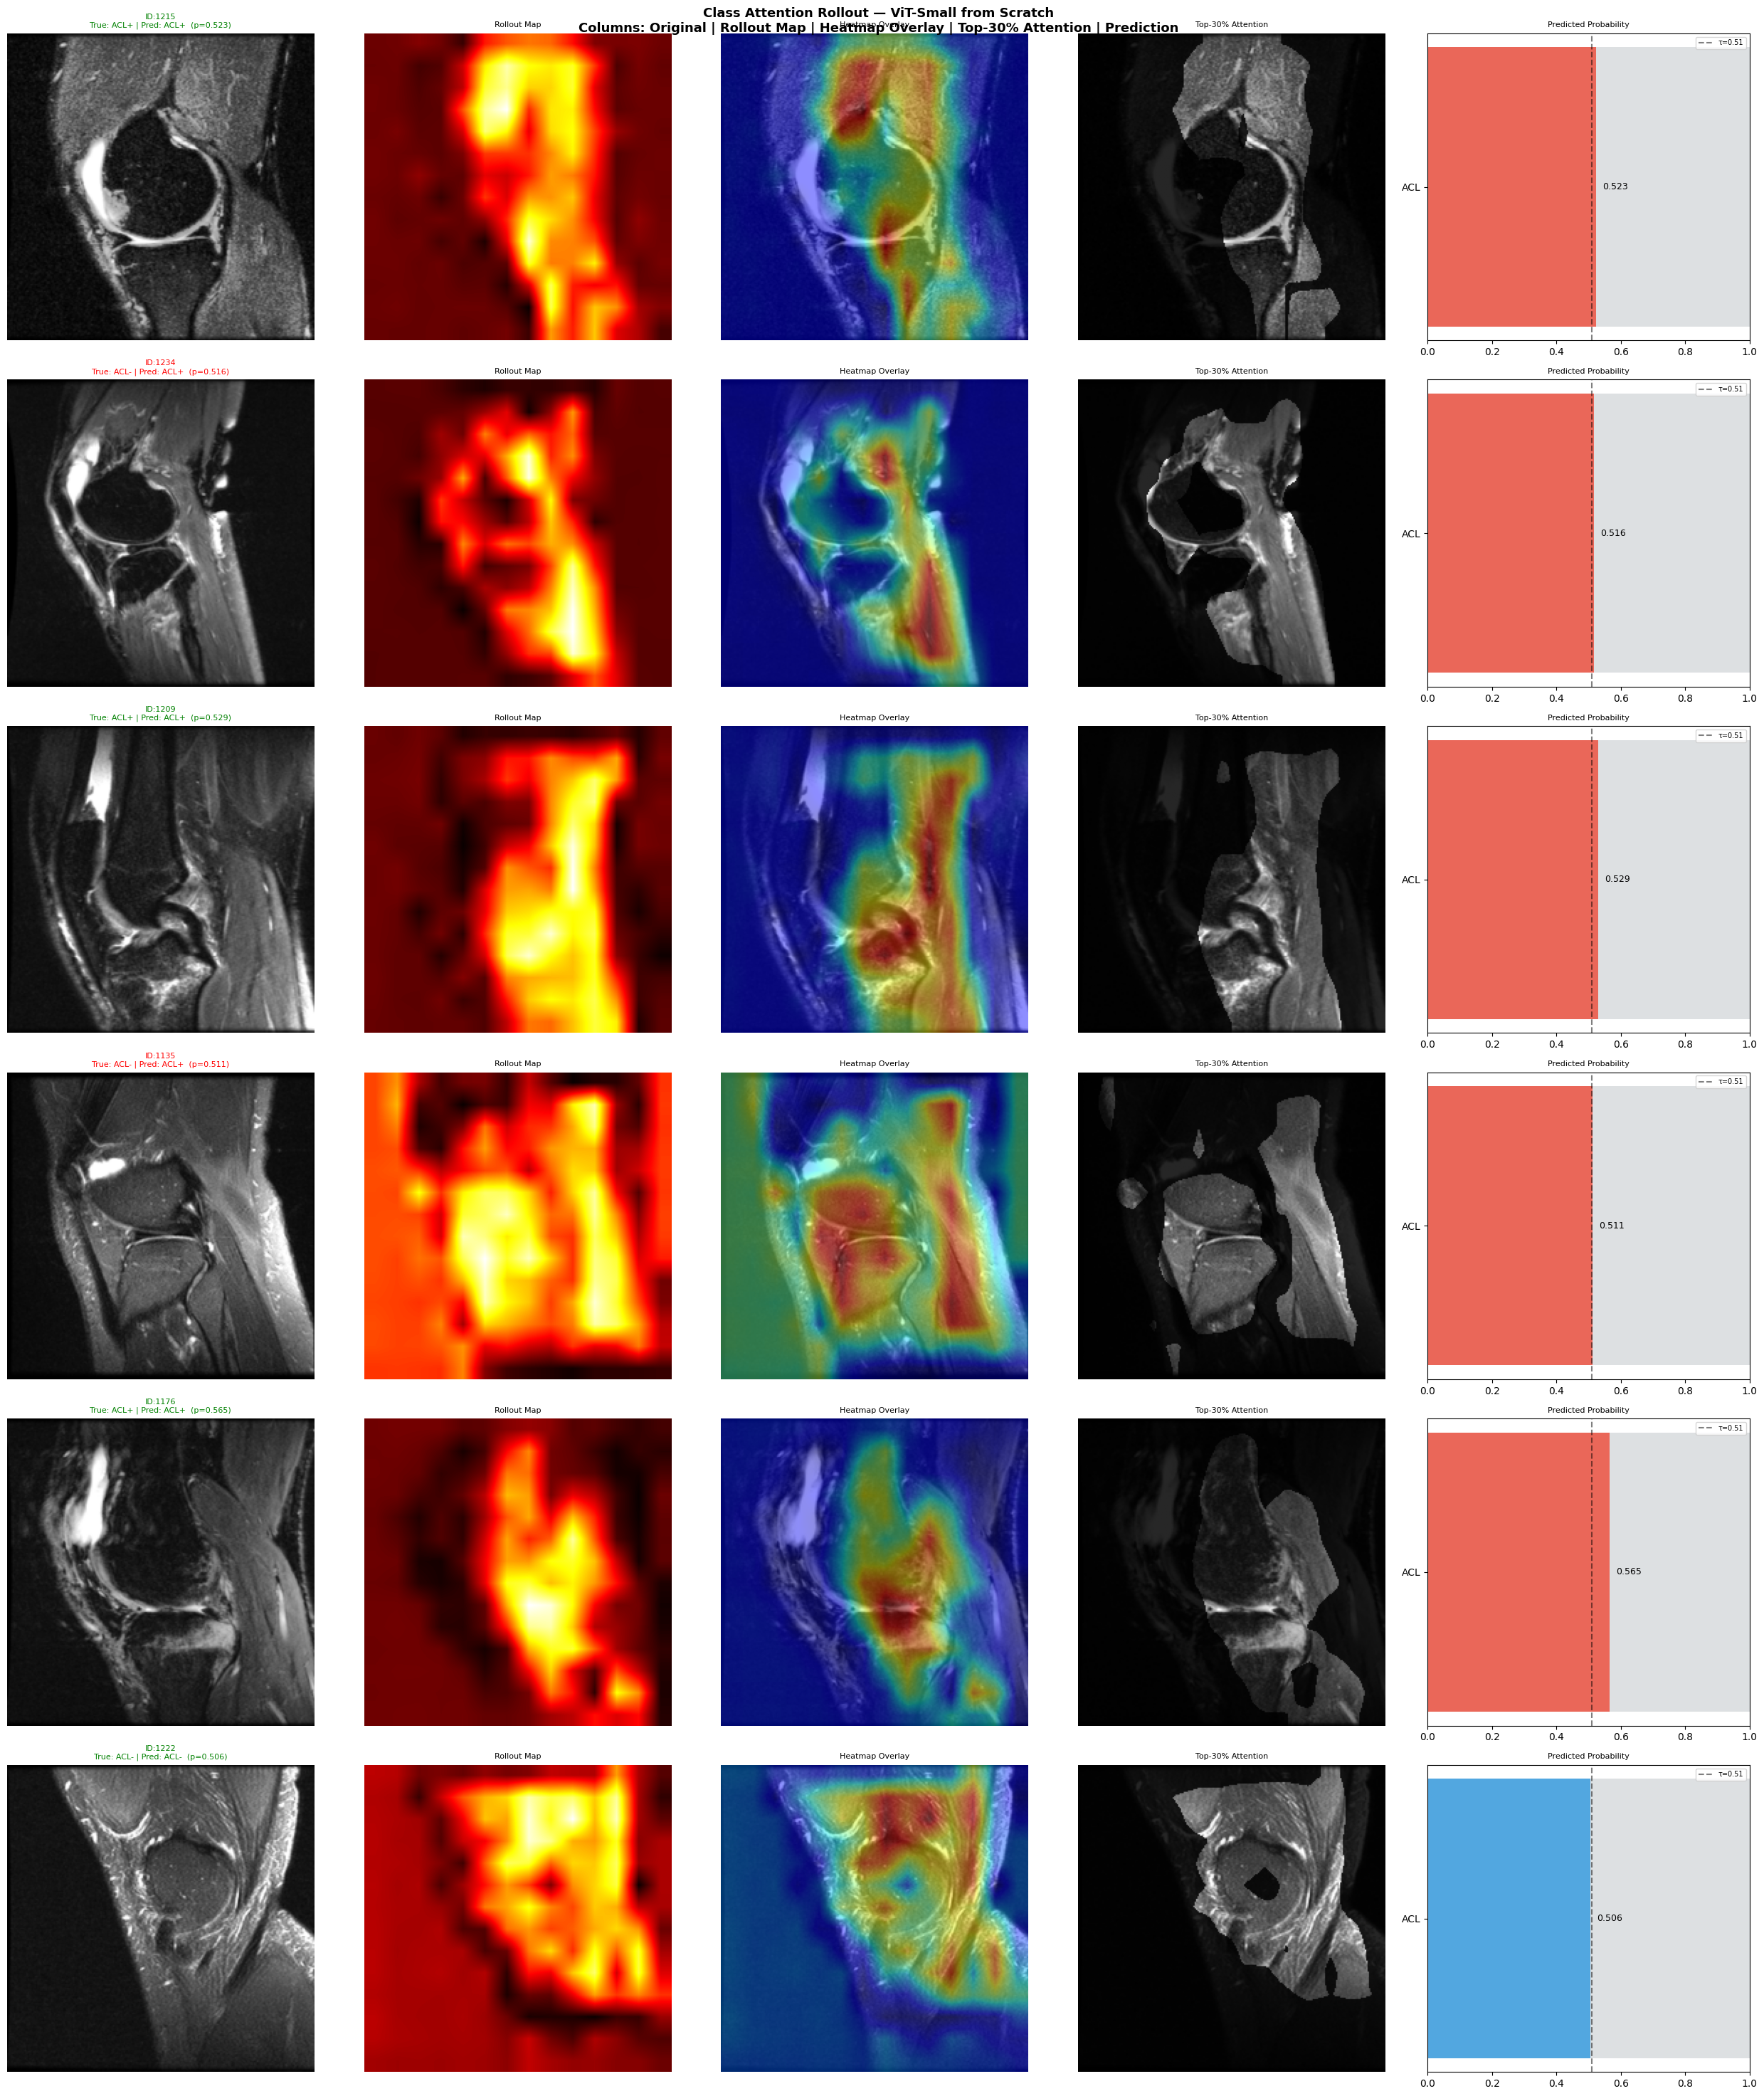

✓ Saved: attention_maps.png


In [74]:
def get_attention_rollout(model, img_tensor, device):
    """
    Attention Rollout (Abnar & Zuidema, 2020).
    Recursively propagates attention across all 12 transformer layers.
    Returns a (14, 14) spatial attention map normalised to [0, 1].
    """
    model.eval()
    # Disable fused attention to expose attention weights
    for block in model.backbone.blocks:
        block.attn.fused_attn = False

    attn_list, hooks = [], []

    def make_hook():
        def hook(module, inp, out):
            attn_list.append(out.detach().cpu())
        return hook

    for block in model.backbone.blocks:
        hooks.append(block.attn.attn_drop.register_forward_hook(make_hook()))

    with torch.no_grad():
        _ = model.backbone(img_tensor.unsqueeze(0).to(device))

    for h in hooks:
        h.remove()
    for block in model.backbone.blocks:
        block.attn.fused_attn = True

    n = attn_list[0].shape[-1]  # 197 = 196 patches + 1 CLS
    R = torch.eye(n)
    for attn in attn_list:
        # Average across heads, add residual connection
        A = attn[0].mean(0) + torch.eye(n)
        A = A / A.sum(-1, keepdim=True)
        R = torch.matmul(A, R)

    # CLS to patch attention (skip CLS-to-CLS)
    cls_attn = R[0, 1:].numpy()
    g        = int(cls_attn.shape[0] ** 0.5)  # 14
    cls_attn = cls_attn.reshape(g, g)
    return (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)


def denorm_img(t, mean, std):
    """Reverse normalisation for display."""
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (t * s + m).clamp(0, 1)


def plot_attention_maps(model, dataset, device, n=6, seed=42):
    model.eval()
    rng  = np.random.default_rng(seed)
    # Select n/2 positive and n/2 negative scans for balanced display
    pos_idx = dataset.df[dataset.df["label"]==1].index.tolist()
    neg_idx = dataset.df[dataset.df["label"]==0].index.tolist()
    n_pos   = n // 2
    n_neg   = n - n_pos
    idxs    = (rng.choice(pos_idx, min(n_pos, len(pos_idx)), replace=False).tolist() +
               rng.choice(neg_idx, min(n_neg, len(neg_idx)), replace=False).tolist())
    rng.shuffle(idxs)

    fig, axes = plt.subplots(n, 5, figsize=(25, 5*n))
    fig.suptitle(
        "Class Attention Rollout — ViT-Small from Scratch\n"
        "Columns: Original | Rollout Map | Heatmap Overlay | Top-30% Attention | Prediction",
        fontsize=13, fontweight="bold"
    )

    for ri, idx in enumerate(idxs):
        img_t, tgt, eid = dataset[int(idx)]
        true_label = "ACL+" if tgt[0] > 0.5 else "ACL-"

        with torch.no_grad():
            logit = model(img_t.unsqueeze(0).to(device))
            prob  = torch.sigmoid(logit).item()
        pred_label = "ACL+" if prob >= CFG.THRESHOLD else "ACL-"
        correct    = true_label == pred_label

        attn   = get_attention_rollout(model, img_t, device)
        img_np = denorm_img(img_t, MRNET_MEAN, MRNET_STD).permute(1,2,0).numpy()
        mid_ch = img_np[:,:,1]  # use green channel as grayscale

        # Col 0: Original
        axes[ri,0].imshow(mid_ch, cmap="gray")
        axes[ri,0].axis("off")
        axes[ri,0].set_title(
            f"ID:{eid}\nTrue: {true_label} | Pred: {pred_label}  (p={prob:.3f})",
            color="green" if correct else "red", fontsize=8
        )

        # Col 1: Raw rollout map
        axes[ri,1].imshow(attn, cmap="hot", interpolation="bilinear")
        axes[ri,1].set_title("Rollout Map", fontsize=8)
        axes[ri,1].axis("off")

        # Col 2: Overlay
        attn_up = np.array(
            Image.fromarray((attn*255).astype(np.uint8)).resize(
                (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE), Image.BILINEAR)
        ) / 255.0
        axes[ri,2].imshow(mid_ch, cmap="gray")
        axes[ri,2].imshow(attn_up, cmap="jet", alpha=0.45)
        axes[ri,2].set_title("Heatmap Overlay", fontsize=8)
        axes[ri,2].axis("off")

        # Col 3: Top-30% attention
        mask = mid_ch.copy()
        mask[attn_up < np.percentile(attn_up, 70)] *= 0.15
        axes[ri,3].imshow(mask, cmap="gray")
        axes[ri,3].set_title("Top-30% Attention", fontsize=8)
        axes[ri,3].axis("off")

        # Col 4: Probability bar
        color = "#E74C3C" if prob >= CFG.THRESHOLD else "#3498DB"
        axes[ri,4].barh(["ACL"], [prob], color=color, alpha=0.85)
        axes[ri,4].barh(["ACL"], [1-prob], left=[prob], color="#BDC3C7", alpha=0.5)
        axes[ri,4].axvline(CFG.THRESHOLD, color="black", linestyle="--", alpha=0.5,
                            label=f"τ={CFG.THRESHOLD:.2f}")
        axes[ri,4].set_xlim([0, 1])
        axes[ri,4].text(prob + 0.02, 0, f"{prob:.3f}", va="center", fontsize=9)
        axes[ri,4].set_title("Predicted Probability", fontsize=8)
        axes[ri,4].legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(CFG.OUT_DIR / "attention_maps.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Saved: attention_maps.png")


plot_attention_maps(model, valid_ds, CFG.DEVICE, n=6)

## Section 16 — Internet Image Testing & Domain Shift

The model was trained on Stanford MRNet 3D volumes. Internet MRI images differ in:
1. **Scanner protocol** — different field strengths (1.5T/3T), manufacturers, contrast settings
2. **Dimensionality** — model expects 3D volumes; internet images are single 2D slices without volumetric context
3. **Preprocessing** — no variance-based slice selection is possible with a single image; the same image fills all 3 channels
4. **Normalisation** — internet images are JPEG-compressed and not normalised to MRNet statistics
5. **Population** — MRNet is US sports medicine patients; internet images represent broader demographics

**Expected finding:** probabilities closer to 0.5 (lower confidence), and potentially different calibration. This is the correct outcome to report — the model is appropriately uncertain on out-of-distribution data.

In [75]:
# Add URLs below — search "ACL tear sagittal plane MRI" on radiopaedia.org
INTERNET_IMAGES = [
    {"url": "https://medality.com/wp-content/uploads/2024/07/Coronal20PD20FS200001.png",
     "true_label": "Unknown", "note": "Coronal PD FS knee MRI"},
    # Add more URLs here:
    # {"url": "URL", "true_label": "ACL+", "note": "ACL tear sagittal"},
    # {"url": "URL", "true_label": "ACL-", "note": "Normal sagittal"},
]


def load_image_from_url(url, timeout=15):
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout) as r:
            return Image.open(BytesIO(r.read())).convert("RGB")
    except Exception as e:
        print(f"  Could not load {url}: {e}")
        return None


@torch.no_grad()
def predict_2d_internet(model, pil_img, device):
    """
    Run a single 2D internet image through the model.
    Since we only have one slice (not a 3D volume), replicate it across all 3
    channels. This is not ideal — the model expects 3 different high-variance
    slices — but it's the best possible approach for a 2D input.
    """
    model.eval()
    t     = valid_tfm(pil_img).unsqueeze(0).to(device)
    prob  = torch.sigmoid(model(t)).item()
    pred  = "ACL+" if prob >= CFG.THRESHOLD else "ACL-"
    return prob, pred


print(f"{'Source':<40} {'Prob':>6} {'Pred':>6}  Note")
print("─" * 75)

internet_results = []
for item in INTERNET_IMAGES:
    img = load_image_from_url(item["url"])
    if img is None:
        continue
    prob, pred = predict_2d_internet(model, img, CFG.DEVICE)
    internet_results.append({**item, "prob": prob, "pred": pred, "img": img})
    print(f"  {item['note']:<38} {prob:>6.3f} {pred:>6}  true={item['true_label']}")

if not internet_results:
    print("(No internet images loaded — add URLs above)")

Source                                     Prob   Pred  Note
───────────────────────────────────────────────────────────────────────────
  Coronal PD FS knee MRI                  0.506   ACL-  true=Unknown


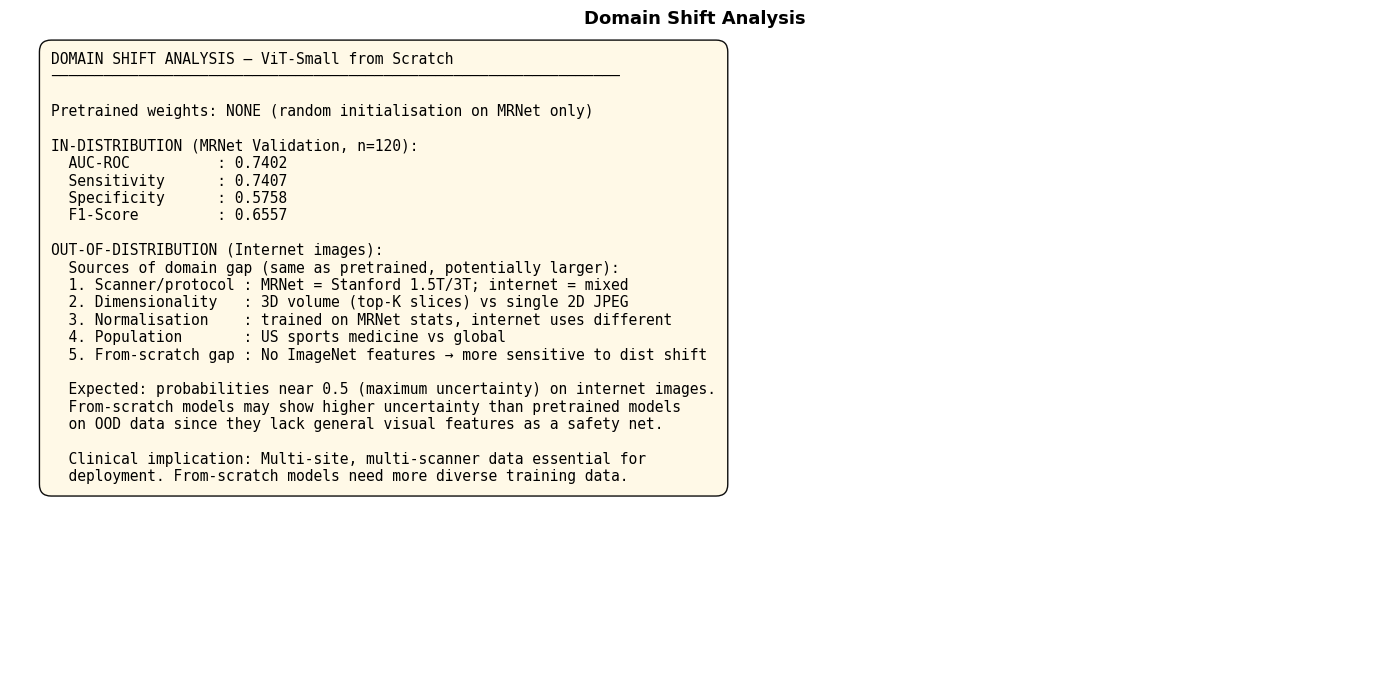

✓ Saved: domain_shift.png


In [76]:
# Domain shift summary figure
val_auc_final = roc_auc_score(y_true, y_probs_tta)

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")
text = (
    f"DOMAIN SHIFT ANALYSIS — ViT-Small from Scratch\n"
    f"{'─'*65}\n\n"
    f"Pretrained weights: NONE (random initialisation on MRNet only)\n\n"
    f"IN-DISTRIBUTION (MRNet Validation, n={len(valid_df)}):\n"
    f"  AUC-ROC          : {val_auc_final:.4f}\n"
    f"  Sensitivity      : {metrics['Sensitivity']:.4f}\n"
    f"  Specificity      : {metrics['Specificity']:.4f}\n"
    f"  F1-Score         : {metrics['F1-Score']:.4f}\n\n"
    f"OUT-OF-DISTRIBUTION (Internet images):\n"
    f"  Sources of domain gap (same as pretrained, potentially larger):\n"
    f"  1. Scanner/protocol : MRNet = Stanford 1.5T/3T; internet = mixed\n"
    f"  2. Dimensionality   : 3D volume (top-K slices) vs single 2D JPEG\n"
    f"  3. Normalisation    : trained on MRNet stats, internet uses different\n"
    f"  4. Population       : US sports medicine vs global\n"
    f"  5. From-scratch gap : No ImageNet features → more sensitive to dist shift\n\n"
    f"  Expected: probabilities near 0.5 (maximum uncertainty) on internet images.\n"
    f"  From-scratch models may show higher uncertainty than pretrained models\n"
    f"  on OOD data since they lack general visual features as a safety net.\n\n"
    f"  Clinical implication: Multi-site, multi-scanner data essential for\n"
    f"  deployment. From-scratch models need more diverse training data."
)
ax.text(0.03, 0.97, text, transform=ax.transAxes, fontsize=10.5,
        va="top", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.8", facecolor="#FFF9E6", alpha=0.95))
ax.set_title("Domain Shift Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR / "domain_shift.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: domain_shift.png")

## Section 17 — Final Summary & Spec Checklist

In [77]:
val_auc_final = roc_auc_score(y_true, y_probs_tta)

print("=" * 70)
print("  FINAL RESULTS — ViT-Small from Scratch | Binary ACL | Sagittal")
print("=" * 70)
print(f"  Pretrained weights : NONE")
print(f"  Total parameters   : {total:,}  ({total/1e6:.2f}M)")
print(f"  Plane              : {CFG.PLANE}")
print(f"  Task               : Binary ACL classification")
print(f"  Loss               : Focal BCE (γ={CFG.FOCAL_GAMMA}, α={CFG.FOCAL_ALPHA})")
print(f"  Base LR            : {CFG.BASE_LR:.2e} (backbone), {CFG.HEAD_LR:.2e} (head)")
print(f"  Weight decay       : {CFG.WEIGHT_DECAY}")
print(f"  Warmup             : {CFG.WARMUP_EPOCHS} epochs")
print(f"  Mix augment        : MixUp(α={CFG.MIXUP_ALPHA}) + CutMix(α={CFG.CUTMIX_ALPHA})")
print(f"  Drop path rate     : {CFG.DROP_PATH_RATE}")
print(f"  TTA passes         : {CFG.TTA_N}")
print(f"  Threshold          : {CFG.THRESHOLD:.2f} (F1-optimal)")
print()
print("  VALIDATION METRICS (with TTA):")
for k, v in metrics.items():
    print(f"    {k:<22}: {v:.4f}")
print()

checklist = [
    ("Dataset loading + DataLoader",             "✓ Sec 3, 7"),
    ("Resize 128 → 224",                         "✓ Sec 5"),
    ("Augmentation ±20°, translate, scale",      "✓ Sec 5"),
    ("ViT-Small via timm (no pretrained)",       "✓ Sec 8"),
    ("Dataset-specific normalisation (MRNet)",   "✓ Sec 5"),
    ("Differential LR backbone vs head",         "✓ Sec 9"),
    ("Hyperparameter tuning",                    "✓ CFG + Sec 9"),
    ("TensorBoard training plots",               "✓ Sec 11"),
    ("Training curves",                          "✓ Sec 12"),
    ("Accuracy + confusion matrix",              "✓ Sec 14"),
    ("Sensitivity / Specificity / F1 / AUC",    "✓ Sec 14"),
    ("Balanced Accuracy",                        "✓ Sec 14"),
    ("Class attention rollout maps",             "✓ Sec 15"),
    ("Internet images + domain shift",           "✓ Sec 16"),
    ("EXTRA: MixUp + CutMix",                   "✓ Sec 9"),
    ("EXTRA: Focal Loss",                        "✓ Sec 9"),
    ("EXTRA: WeightedRandomSampler",             "✓ Sec 6"),
    ("EXTRA: TTA (8 passes)",                   "✓ Sec 13"),
    ("EXTRA: Threshold optimisation",            "✓ Sec 13"),
    ("EXTRA: MRNet statistics (not ImageNet)",  "✓ Sec 5"),
    ("EXTRA: Long warmup for scratch ViT",      "✓ Sec 9"),
]
print("SPEC CHECKLIST:")
print("─" * 58)
for req, status in checklist:
    print(f"  {status:<18} {req}")
print()
print(f"Output files in: {CFG.OUT_DIR}")
for f in sorted(list(CFG.OUT_DIR.glob("*.png")) + list(CFG.OUT_DIR.glob("*.csv"))):
    print(f"  ✓ {f.name}")

  FINAL RESULTS — ViT-Small from Scratch | Binary ACL | Sagittal
  Pretrained weights : NONE
  Total parameters   : 21,798,017  (21.80M)
  Plane              : sagittal
  Task               : Binary ACL classification
  Loss               : Focal BCE (γ=2.0, α=0.6)
  Base LR            : 5.00e-05 (backbone), 1.00e-04 (head)
  Weight decay       : 0.05
  Warmup             : 5 epochs
  Mix augment        : MixUp(α=0.4) + CutMix(α=1.0)
  Drop path rate     : 0.15
  TTA passes         : 8
  Threshold          : 0.51 (F1-optimal)

  VALIDATION METRICS (with TTA):
    Accuracy              : 0.6500
    Balanced Accuracy     : 0.6582
    Sensitivity           : 0.7407
    Specificity           : 0.5758
    Precision             : 0.5882
    F1-Score              : 0.6557
    AUC-ROC               : 0.7402

SPEC CHECKLIST:
──────────────────────────────────────────────────────────
  ✓ Sec 3, 7         Dataset loading + DataLoader
  ✓ Sec 5            Resize 128 → 224
  ✓ Sec 5            Augm